In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../dataset/retail_store_inventory.csv")


In [3]:
#Pemusatan data
df.describe()

,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Holiday/Promotion,Competitor Pricing
count,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,274.469877,136.464870,110.004473,141.494720,55.135108,10.009508,0.497305,55.146077
std,129.949514,108.919406,52.277448,109.254076,26.021945,7.083746,0.499996,26.191408
min,50.000000,0.000000,20.000000,-9.990000,10.000000,0.000000,0.000000,5.030000
25%,162.000000,49.000000,65.000000,53.670000,32.650000,5.000000,0.000000,32.680000
50%,273.000000,107.000000,110.000000,113.015000,55.050000,10.000000,0.000000,55.010000
75%,387.000000,203.000000,155.000000,208.052500,77.860000,15.000000,1.000000,77.820000
max,500.000000,499.000000,200.000000,518.550000,100.000000,20.000000,1.000000,104.940000


In [4]:
#Check for missing values
missing_values = df.isnull().sum()
print(missing_values)

Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Demand Forecast       0
Price                 0
Discount              0
Weather Condition     0
Holiday/Promotion     0
Competitor Pricing    0
Seasonality           0
dtype: int64


In [5]:
#Feature Engineering
df['Date'] = pd.to_datetime(
    df['Date'],
    dayfirst=True,
    format='mixed',
    errors='coerce'
)
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['day'] = df['Date'].dt.day
df['weekday'] = df['Date'].dt.weekday
df['Discount_Flag'] = np.where(df['Discount'] > 0, 1, 0)
df['Price_Diff_vs_Competitor'] = df['Price'] - df['Competitor Pricing']

df.head()

#1. Convert date to datetiem format
#2. Discount flag = binary indicator for discount or not
#3. Price difference between store and competitor

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,...,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality,year,month,day,weekday,Discount_Flag,Price_Diff_vs_Competitor
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,...,Rainy,0,29.69,Autumn,2022,1,1,5,1,3.81
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,...,Sunny,0,66.16,Autumn,2022,1,1,5,1,-3.15
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,...,Sunny,1,31.32,Summer,2022,1,1,5,1,-3.33
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,...,Cloudy,1,34.74,Autumn,2022,1,1,5,1,-2.02
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,...,Sunny,0,68.95,Summer,2022,1,1,5,0,4.69


In [6]:
#drop the original data column, we have separate into tear month day weekday
df.drop('Date', axis=1, inplace=True)
df.head()

,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality,year,month,day,weekday,Discount_Flag,Price_Diff_vs_Competitor
0,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn,2022,1,1,5,1,3.81
1,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn,2022,1,1,5,1,-3.15
2,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer,2022,1,1,5,1,-3.33
3,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn,2022,1,1,5,1,-2.02
4,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer,2022,1,1,5,0,4.69


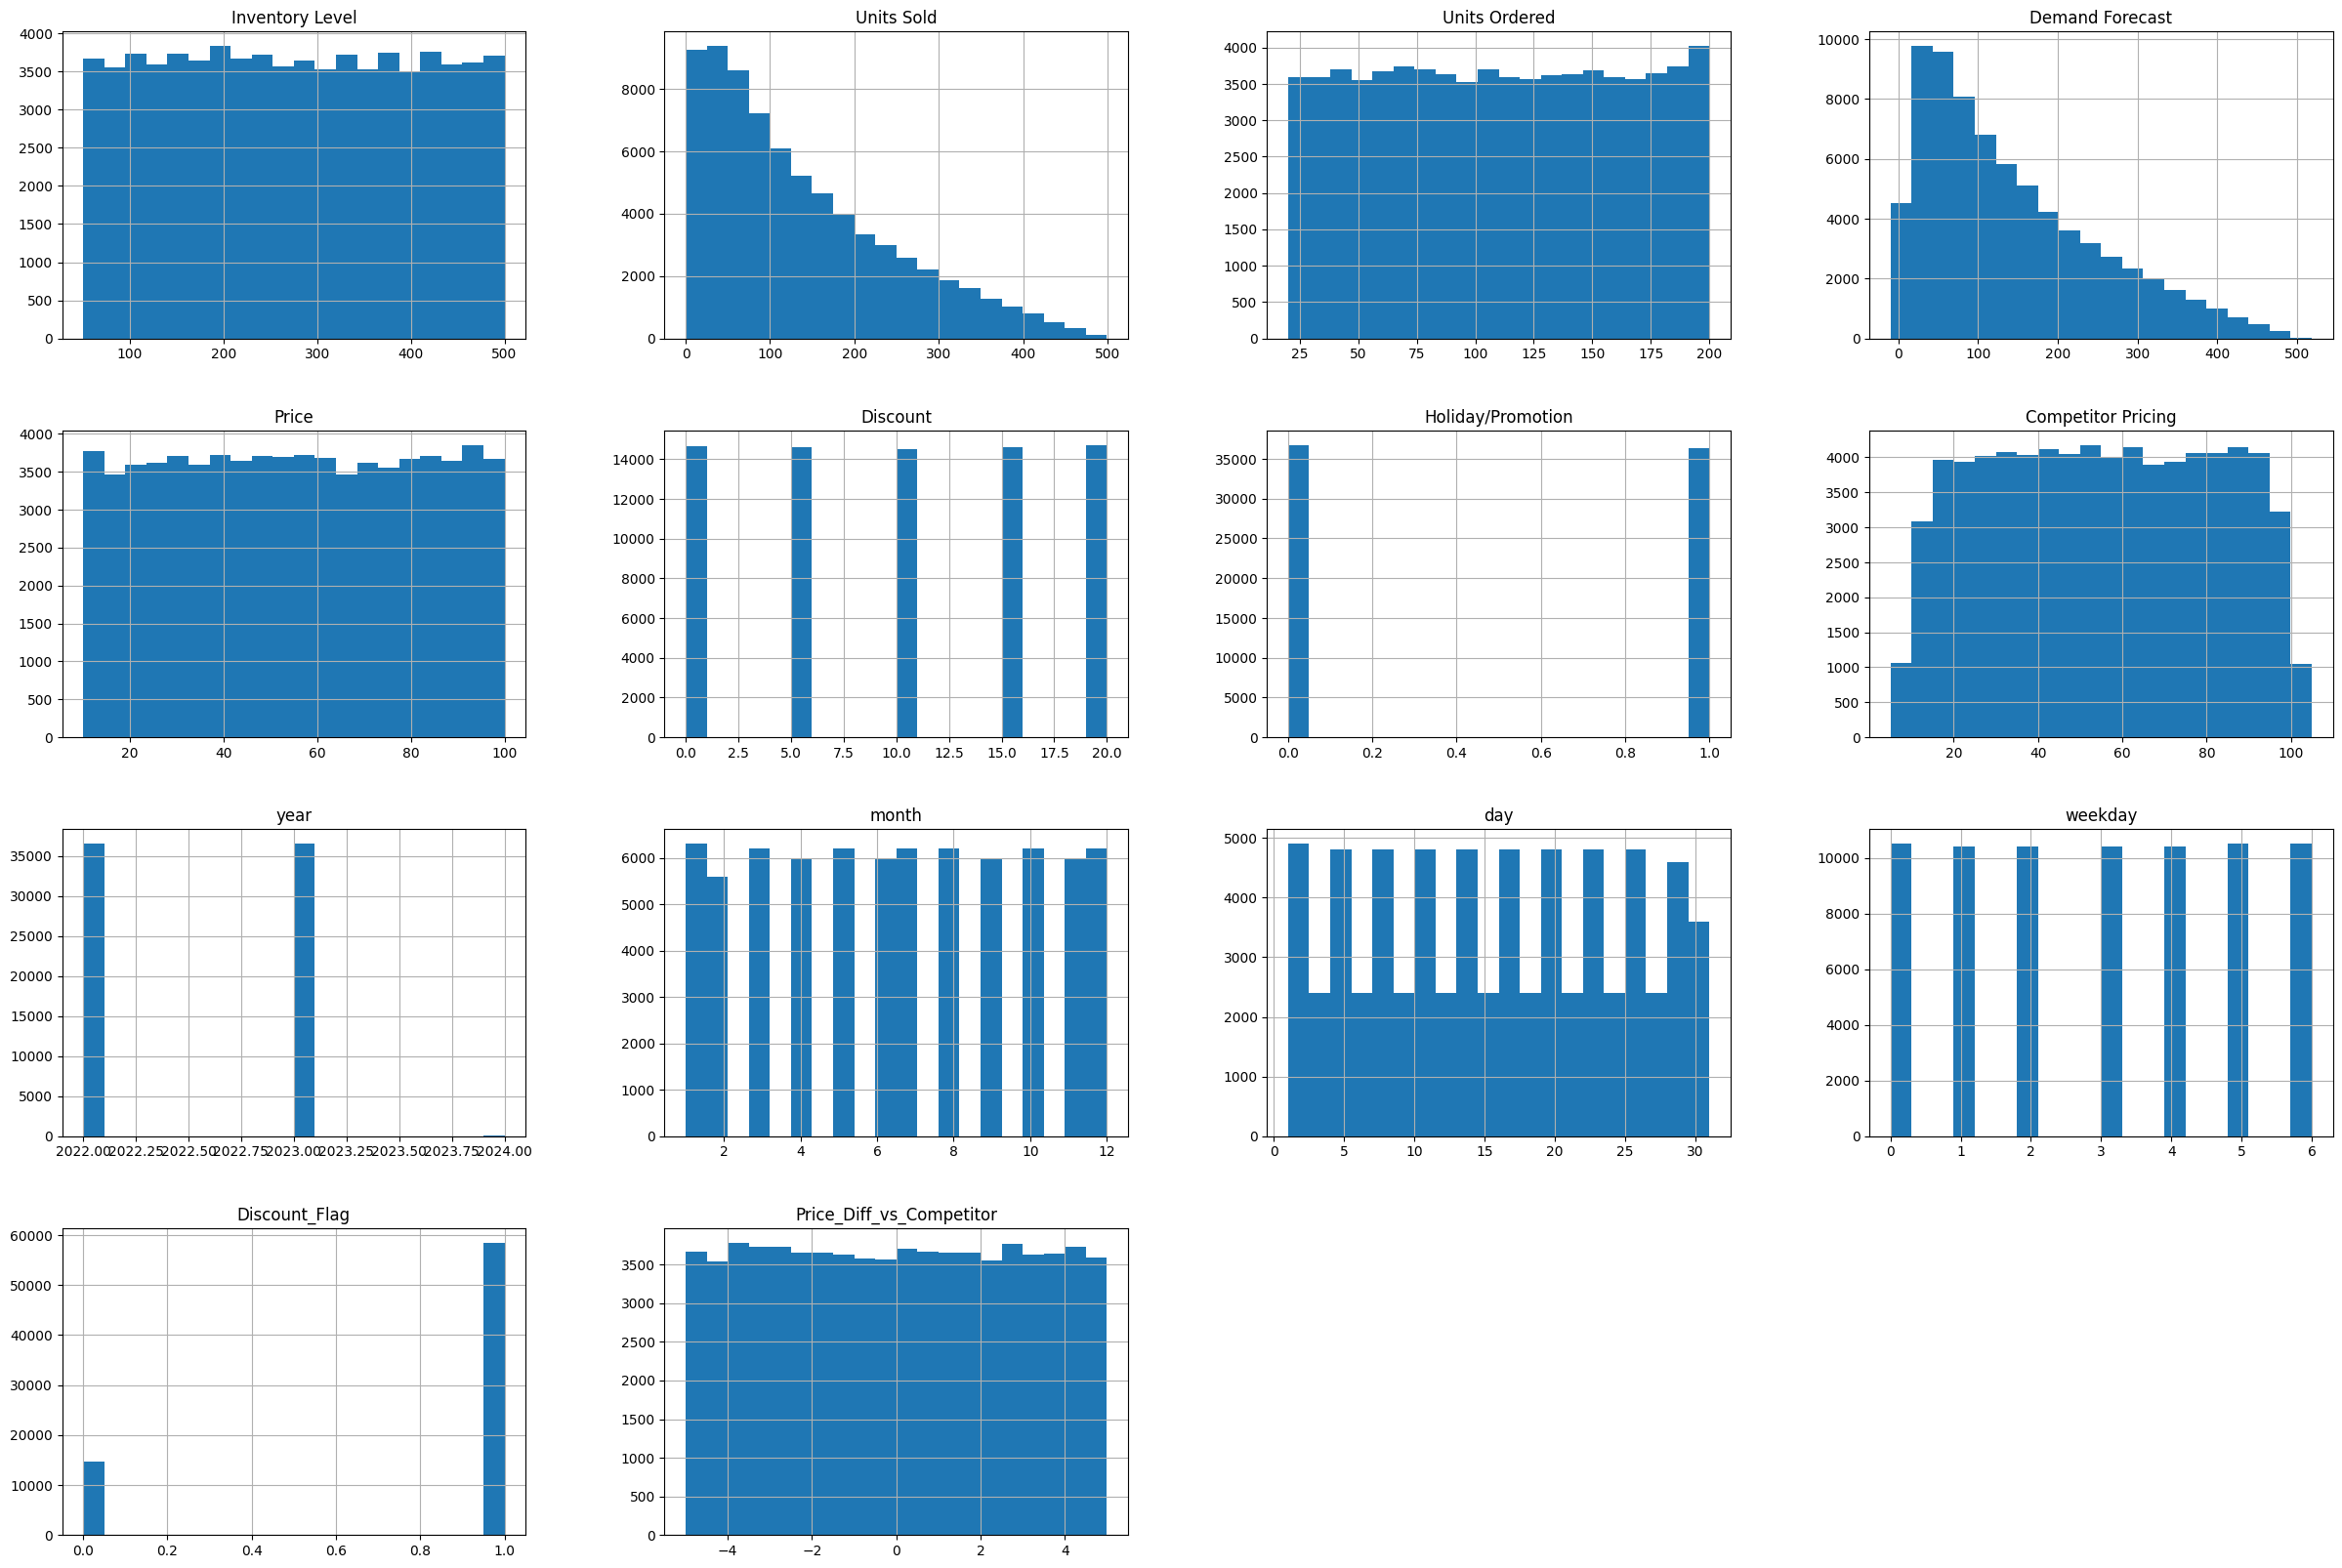

In [7]:
#EDA
df.hist(bins=20, figsize=(30,20))
plt.show()

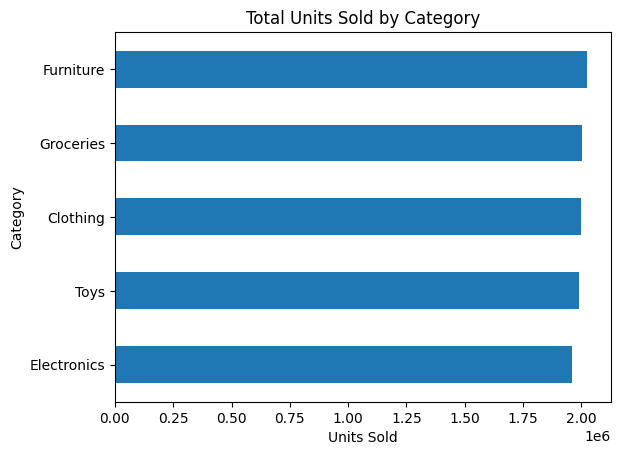

In [8]:
#Total units sold by category
#We target only Groceries first
category_sales = df.groupby('Category')['Units Sold'].sum().sort_values()

category_sales.plot(kind='barh')
plt.title("Total Units Sold by Category")
plt.xlabel("Units Sold")
plt.show()

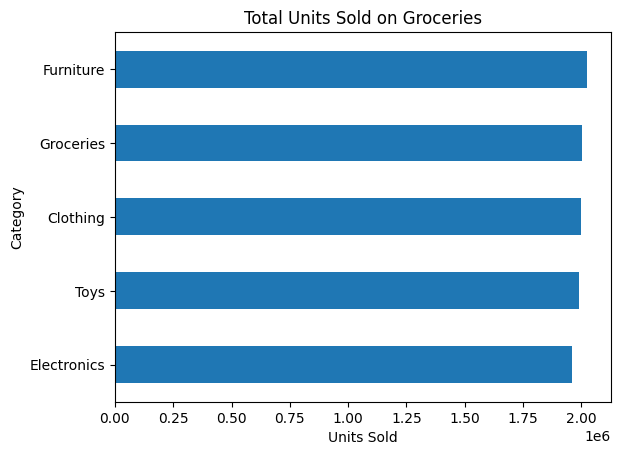

In [9]:
category_sales = df.groupby('Category')['Units Sold'].sum().sort_values()

category_sales.plot(kind='barh')
plt.title("Total Units Sold on Groceries")
plt.xlabel("Units Sold")
plt.show()

In [10]:
#Model training - import library
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error

from xgboost import XGBRegressor

In [11]:
#Label encoding - turn categorical into numeric
label_encoder = LabelEncoder()

categorical_columns = [
    'Store ID',
    'Product ID',
    'Category',
    'Region',
    'Weather Condition',
    'Competitor Pricing',
    'Seasonality'
]

for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])

df.head()

,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality,year,month,day,weekday,Discount_Flag,Price_Diff_vs_Competitor
0,0,0,3,1,231,127,55,135.47,33.50,20,1,0,2345,0,2022,1,1,5,1,3.81
1,0,1,4,2,204,150,66,144.04,63.01,20,3,0,5990,0,2022,1,1,5,1,-3.15
2,0,2,4,3,102,65,51,74.02,27.99,10,3,1,2508,2,2022,1,1,5,1,-3.33
3,0,3,4,1,469,61,164,62.18,32.72,10,0,1,2850,0,2022,1,1,5,1,-2.02
4,0,4,1,0,166,14,135,9.26,73.64,0,3,0,6269,2,2022,1,1,5,0,4.69


In [12]:
#Define features (X) and target (Y)
# Input features (X) → information used to predict [DROP TARGET for model use other colums]
# Target (y) → the answer we want the model to learn
y = df['Units Sold']
x = df.drop('Units Sold', axis=1)

In [13]:
#Split train and test
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [14]:
#Model uses XGBRegressoer - Extreme Gradient Boosting Regressor
model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

In [15]:
#Input paramters and target for trainign in fit()
model.fit(X_train,y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [16]:
#Make Predictions
y_predict = model.predict(X_test)

In [26]:
#Evalulate model - use MAE, MSE, RMSE
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
# MAE → business friendly
# RMSE → model quality
# R2 score ->  measure how well the predictions approximate the actual data points [REGRESSION MODEL] 0 to 1

mae = mean_absolute_error(y_test,y_predict)
mse = mean_squared_error(y_test, y_predict)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_predict)

print("MAE: ", mae)
print("MSE: ", mse)
print("RMSE: ", rmse)
print("R2 Score: ", r2)


MAE:  7.161528587341309
MSE:  70.79474639892578
RMSE:  8.413961397518163
R2 Score:  0.9940205216407776


In [18]:
#Save model with joblib
import joblib
joblib.dump(model, "predict_demand_model.pkl")

#Load model later
#model = joblib.load("demand_model.pkl")

['predict_demand_model.pkl']

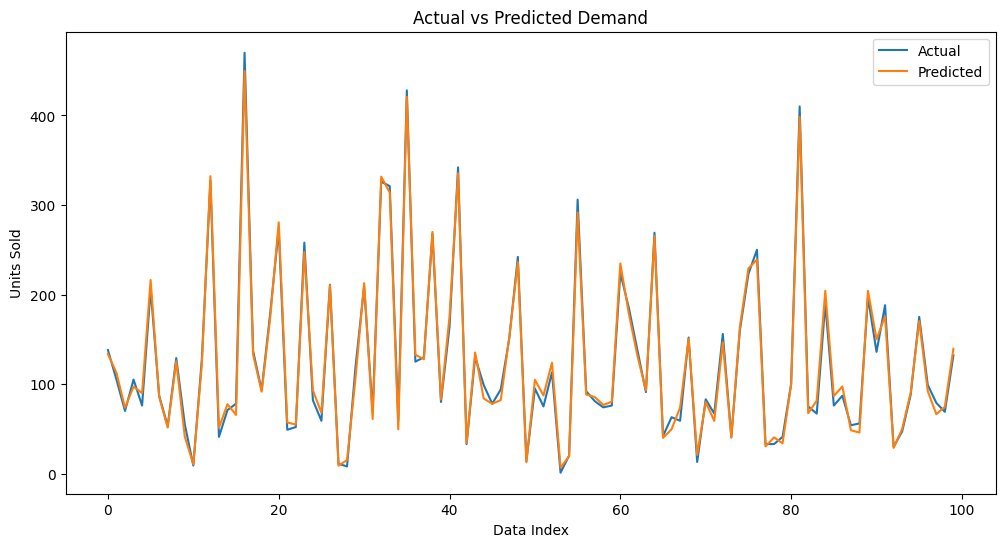

In [27]:
#Show predicted values by model and actual data
plt.figure(figsize=(12,6))

plt.plot(y_test.values[:100], label='Actual')
plt.plot(y_predict[:100], label='Predicted')

plt.legend()

plt.xlabel("Data Index")
plt.ylabel("Units Sold")

plt.title("Actual vs Predicted Demand")
plt.show()

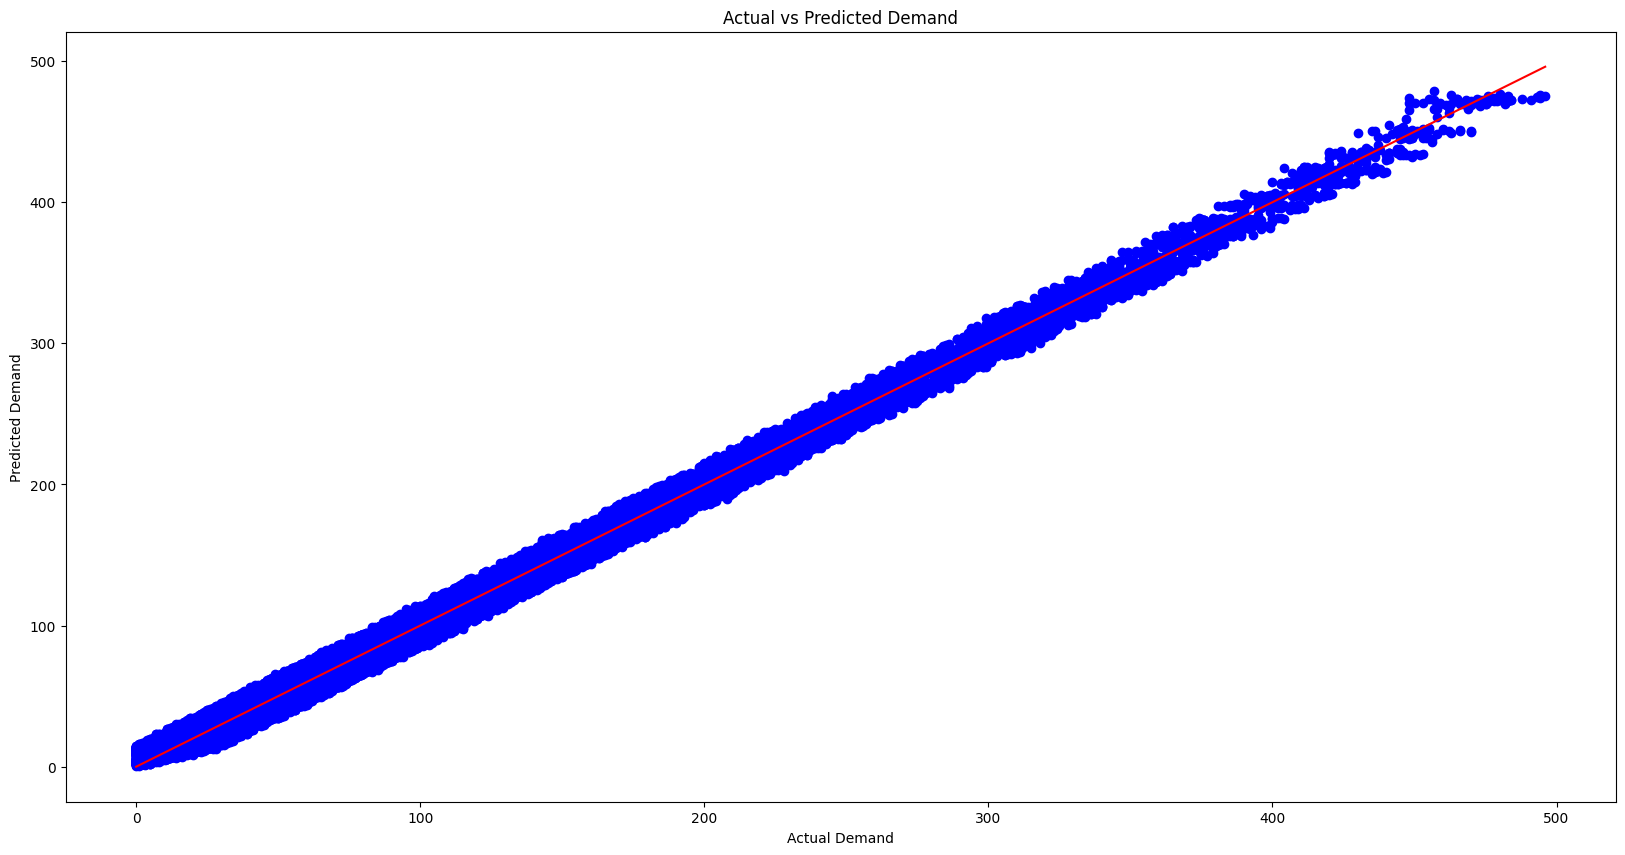

In [25]:
plt.figure(figsize=(20,10))

plt.scatter(
    y_test,
    y_predict,
    color='blue',
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.title("Actual vs Predicted Demand")

plt.show()